<a href="https://colab.research.google.com/github/yaduvamsikrishna2004/Tredence_project/blob/main/Tredence_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch torchvision matplotlib

100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s]



Training with λ = 1e-05

Epoch [1/20] Loss: 3846.2316
Epoch [2/20] Loss: 3286.9678
Epoch [3/20] Loss: 2833.2882
Epoch [4/20] Loss: 2451.0606
Epoch [5/20] Loss: 2136.6696
Epoch [6/20] Loss: 1883.5066
Epoch [7/20] Loss: 1685.9262
Epoch [8/20] Loss: 1526.2193
Epoch [9/20] Loss: 1399.9282
Epoch [10/20] Loss: 1300.8565
Epoch [11/20] Loss: 1214.0785
Epoch [12/20] Loss: 1145.6368
Epoch [13/20] Loss: 1086.6349
Epoch [14/20] Loss: 1035.9845
Epoch [15/20] Loss: 993.6385
Epoch [16/20] Loss: 956.5967
Epoch [17/20] Loss: 922.0222
Epoch [18/20] Loss: 894.9513
Epoch [19/20] Loss: 869.5962
Epoch [20/20] Loss: 845.0390

λ = 1e-05
Accuracy = 53.74%
Sparsity = 35.42%

Training with λ = 0.0001

Epoch [1/20] Loss: 31449.6237
Epoch [2/20] Loss: 26171.2669
Epoch [3/20] Loss: 21368.4585
Epoch [4/20] Loss: 17212.4684
Epoch [5/20] Loss: 13791.0968
Epoch [6/20] Loss: 11082.2975
Epoch [7/20] Loss: 8985.3637
Epoch [8/20] Loss: 7375.9302
Epoch [9/20] Loss: 6133.0638
Epoch [10/20] Loss: 5165.7981
Epoch [11/20] Loss

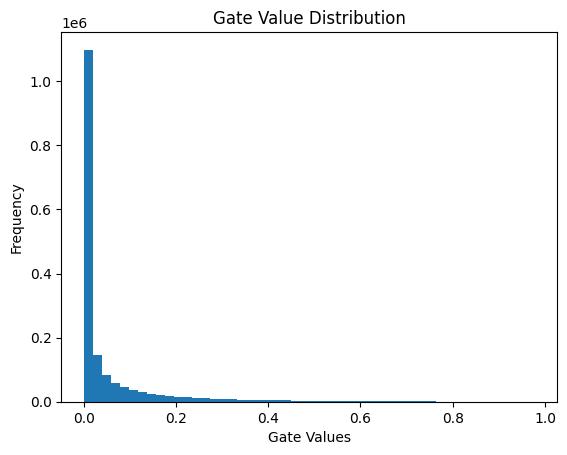

In [1]:
# ============================================
# SELF-PRUNING NEURAL NETWORK (CIFAR-10)
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =========================
# DEVICE CONFIG
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================
# 1. PRUNABLE LINEAR LAYER
# ============================================
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()

        # Normal weights
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Gate scores (learnable)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)  # values between 0 and 1
        pruned_weights = self.weight * gates     # element-wise multiplication
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)


# ============================================
# 2. MODEL DEFINITION
# ============================================
class PrunableNet(nn.Module):
    def __init__(self):
        super(PrunableNet, self).__init__()

        self.fc1 = PrunableLinear(32 * 32 * 3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_all_gates(self):
        gates = []
        for layer in [self.fc1, self.fc2, self.fc3]:
            gates.append(layer.get_gates().view(-1))
        return torch.cat(gates)


# ============================================
# 3. DATA LOADING (CIFAR-10)
# ============================================
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


# ============================================
# 4. TRAINING FUNCTION
# ============================================
def train_model(lambda_sparsity, epochs=20):
    model = PrunableNet().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    print(f"\nTraining with λ = {lambda_sparsity}\n")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            classification_loss = criterion(outputs, labels)

            # Sparsity Loss (L1 of gates)
            gates = model.get_all_gates()
            sparsity_loss = torch.sum(gates)

            total_loss = classification_loss + lambda_sparsity * sparsity_loss

            total_loss.backward()
            optimizer.step()

            running_loss += total_loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss:.4f}")

    return model


# ============================================
# 5. EVALUATION FUNCTION
# ============================================
def evaluate(model):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    # Sparsity calculation
    gates = model.get_all_gates()
    threshold = 1e-2

    zero_weights = (gates < threshold).sum().item()
    total_weights = gates.numel()

    sparsity = 100 * zero_weights / total_weights

    return accuracy, sparsity


# ============================================
# 6. EXPERIMENT LOOP
# ============================================
def run_experiments():
    lambdas = [1e-5, 1e-4, 1e-3]
    results = []

    best_model = None
    best_accuracy = 0

    for lam in lambdas:
        model = train_model(lam)
        acc, sparsity = evaluate(model)

        print(f"\nλ = {lam}")
        print(f"Accuracy = {acc:.2f}%")
        print(f"Sparsity = {sparsity:.2f}%")

        results.append((lam, acc, sparsity))

        if acc > best_accuracy:
            best_accuracy = acc
            best_model = model

    return results, best_model


# ============================================
# 7. PLOT GATE DISTRIBUTION
# ============================================
def plot_gate_distribution(model):
    gates = model.get_all_gates().cpu().detach().numpy()

    plt.hist(gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Values")
    plt.ylabel("Frequency")
    plt.show()


# ============================================
# MAIN EXECUTION
# ============================================
if __name__ == "__main__":

    results, best_model = run_experiments()

    print("\nFINAL RESULTS")
    print("Lambda | Accuracy | Sparsity")
    for r in results:
        print(f"{r[0]} | {r[1]:.2f}% | {r[2]:.2f}%")

    # Plot graph for best model
    plot_gate_distribution(best_model)


Training with λ = 1e-05

Epoch [1/20] Loss: 7655.1610
Epoch [2/20] Loss: 7197.4808
Epoch [3/20] Loss: 6795.0350
Epoch [4/20] Loss: 6418.6045
Epoch [5/20] Loss: 6064.0059
Epoch [6/20] Loss: 5733.8314
Epoch [7/20] Loss: 5429.4783
Epoch [8/20] Loss: 5148.0299
Epoch [9/20] Loss: 4887.6430
Epoch [10/20] Loss: 4648.9208
Epoch [11/20] Loss: 4432.7367
Epoch [12/20] Loss: 4232.7681
Epoch [13/20] Loss: 4051.0180
Epoch [14/20] Loss: 3882.8925
Epoch [15/20] Loss: 3729.3090
Epoch [16/20] Loss: 3588.7214
Epoch [17/20] Loss: 3457.6014
Epoch [18/20] Loss: 3338.4382
Epoch [19/20] Loss: 3227.1581
Epoch [20/20] Loss: 3124.8317

λ = 1e-05
Accuracy = 58.73%
Sparsity = 0.42%

Training with λ = 0.0001

Epoch [1/20] Loss: 69656.7809
Epoch [2/20] Loss: 63961.0170
Epoch [3/20] Loss: 58426.7116
Epoch [4/20] Loss: 53091.8389
Epoch [5/20] Loss: 48015.2357
Epoch [6/20] Loss: 43247.8152
Epoch [7/20] Loss: 38825.0596
Epoch [8/20] Loss: 34768.6314
Epoch [9/20] Loss: 31082.9232
Epoch [10/20] Loss: 27764.1992
Epoch [11

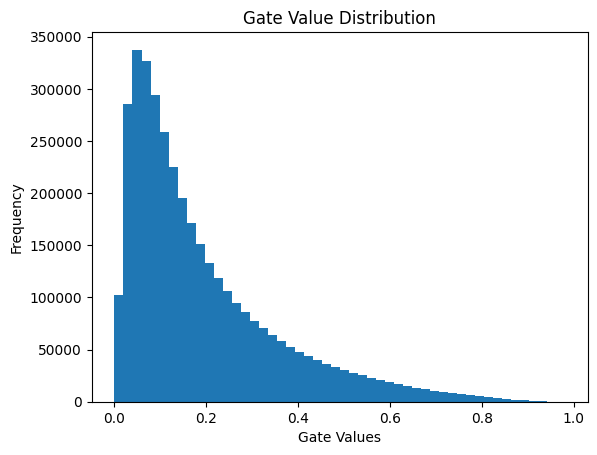

In [2]:
# ============================================
# IMPROVED SELF-PRUNING NEURAL NETWORK
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =========================
# SEED (Reproducibility)
# =========================
torch.manual_seed(42)

# =========================
# DEVICE CONFIG
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================
# 1. PRUNABLE LINEAR LAYER
# ============================================
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        # Better initialization
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.bias = nn.Parameter(torch.zeros(out_features))

        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)


# ============================================
# 2. MODEL (Improved)
# ============================================
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32 * 32 * 3, 1024)
        self.fc2 = PrunableLinear(1024, 512)
        self.fc3 = PrunableLinear(512, 10)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        x = self.fc3(x)
        return x

    def get_all_gates(self):
        gates = []
        for layer in [self.fc1, self.fc2, self.fc3]:
            gates.append(layer.get_gates().view(-1))
        return torch.cat(gates)


# ============================================
# 3. DATA LOADING (Improved)
# ============================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


# ============================================
# 4. TRAINING FUNCTION
# ============================================
def train_model(lambda_sparsity, epochs=20):
    model = PrunableNet().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.CrossEntropyLoss()

    print(f"\nTraining with λ = {lambda_sparsity}\n")

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            classification_loss = criterion(outputs, labels)

            # Sparsity Loss
            gates = model.get_all_gates()
            sparsity_loss = torch.sum(gates)

            loss = classification_loss + lambda_sparsity * sparsity_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss:.4f}")

    return model


# ============================================
# 5. EVALUATION
# ============================================
def evaluate(model):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    gates = model.get_all_gates()
    threshold = 1e-2

    zero_weights = (gates < threshold).sum().item()
    total_weights = gates.numel()

    sparsity = 100 * zero_weights / total_weights

    return accuracy, sparsity


# ============================================
# 6. EXPERIMENTS
# ============================================
def run_experiments():
    lambdas = [1e-5, 1e-4, 1e-3]
    results = []

    best_model = None
    best_accuracy = 0

    for lam in lambdas:
        model = train_model(lam)
        acc, sparsity = evaluate(model)

        print(f"\nλ = {lam}")
        print(f"Accuracy = {acc:.2f}%")
        print(f"Sparsity = {sparsity:.2f}%")

        results.append((lam, acc, sparsity))

        if acc > best_accuracy:
            best_accuracy = acc
            best_model = model

    return results, best_model


# ============================================
# 7. PLOT
# ============================================
def plot_gate_distribution(model):
    gates = model.get_all_gates().cpu().detach().numpy()

    plt.hist(gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Values")
    plt.ylabel("Frequency")
    plt.show()


# ============================================
# MAIN
# ============================================
if __name__ == "__main__":

    results, best_model = run_experiments()

    print("\nFINAL RESULTS")
    print("Lambda | Accuracy | Sparsity")
    for r in results:
        print(f"{r[0]} | {r[1]:.2f}% | {r[2]:.2f}%")

    plot_gate_distribution(best_model)